In [ ]:
# SVM
# 각 데이터의 경계를 구분하는 선(Decision Boundary)을 찾는 알고리즘
# 마진(Margin) : 경계와 가장 가까운 각 클래스 데이터의 샘플사이의 거리
# 마진(Margin) : 경계와 가장 가까운 각 클래스별 서포트 벡터와의 거리
# 서포트 벡터(Support Vector) : 경계와 가장 가까운 클래스 데이터
# 특징 : 지도학습 중 분류 문제 시 굉장히 강력한 성능

In [41]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd



from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
# accuracy(정확도) 는 Classification(분류) , R^2 score(결정계수) 는 Regression(회귀)에 사용
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.datasets import load_iris, make_regression, make_blobs, load_digits

In [ ]:
# Support Vector Classification

svc = SVC(kernel="rbf", C=1.0, random_state=20)
iris_dataset = load_iris()

X_iris = iris_dataset.data
y_iris = iris_dataset.target

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, random_state=20)

svc.fit(X_iris_train , y_iris_train)
y_iris_pred = svc.predict(X_iris_test)

acc_iris = accuracy_score(y_iris_test, y_iris_pred)
print(f"정확도 : {acc_iris:.4f}")

정확도 : 0.9474


In [3]:
# kernel="rbf" : 비션형 커널에 사용 (교제 :P.152, 그림 2-12)
# C : 규제 parameter (더 많은 데이터를 포함하고자 함, 성능 높아짐, 과적합)

iris_dataset = load_iris()

X_iris = iris_dataset.data
y_iris = iris_dataset.target

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, random_state=20)


svc = SVC(kernel="rbf", C=1.0, random_state=20)
# 스케일링 해야한다
# feature 간의 폭(범위)을 일치시키는 작업
# 학습하기 전 데이터를 처리 -> 전처리(Preprocessing)
scaler_iris = StandardScaler()

# X_iris_train 을 scaler 에 학습시키자
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)

X_iris_test_scaled = scaler_iris.transform(X_iris_test)

svc = svc.fit(X_iris_train_scaled , y_iris_train)
y_iris_pred = svc.predict(X_iris_test_scaled)

acc_iris = accuracy_score(y_iris_test, y_iris_pred)
print(f"정확도 : {acc_iris:.4f}")

정확도 : 0.9211


In [4]:
# BMI를 판단하기 위해 키와 몸무게를 기준
# y = a1 * X1 + a2 * X2
# X1 : 키 , X2 : 몸무게
# 키와 몸무게를 같은 범위로 조정
# -> 스케일링
# 정규분포 형태로 수정하는 클래스 -> StadardScaler

In [5]:
# Regression (회귀)
# 수치 예측 
# Linear Regression : 데이터에 가장 적합한 직선을 찾는 알고리즘
# Linear Regression general model : y = w1 * X1 + b

X_reg, y_reg = make_regression(n_samples=1000, n_features= 1, noise=8, random_state= 20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, random_state= 20)

lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
y_reg_pred = lr.predict(X_reg_test)

# acc_reg = accuracy_score(y_reg_test, y_reg_pred)  # error

# R^2 (결정계수)
# 회귀모델의 성능을 보다 직관적으로 표현
# 회귀모델 성능을 100점 만점으로 했을 때, 80점이다!
# SSR(Sum of Square residual) / SST(Sum of Square Total)
# 1 - (SSE / SST)
# 1 - (Sum of Square Error / Sum of Square Total)
# SST
# 그냥 모든 예측이 평균이라고 가정하고 그 오차의 합
# 평균으로 찍었을 때 나온 오차의 합
# SSE
# 실제 우리 모델의 오차

# 우리 모델이 모든 상황을 완벽하게 설명해서
# 오차가 0이 되면 (SSE = 0)
# R^2 = 1 (100점이다)

# 기껏 모델을 학습시켰는데
# SSE가 대충 찍은 SST랑 거의 비슷하다면
# R^2 = 0 (0점이다)

# 만약 R^2가 음수 -> 학습 방향이 잘못됨

r2_reg = r2_score(y_reg_test, y_reg_pred)
print(f"r2 : {r2_reg:.4f}")

r2 : 0.3367


In [6]:
# 얼마나 실제 값과 비슷한지 직접 오차를 구해보자
# 모든 오차를 합했더니 0이 되었습니다, 100% 좋은 모델은 아님
# 오차에 절대값을 씌우자

# mean
MAE = mean_absolute_error(y_reg_test, y_reg_pred)
print(f"{MAE:.4f}")

# Variance (분산)
MSE = mean_squared_error(y_reg_test, y_reg_pred)
print(f"{MSE:.4f}")

# Standard Deviation (표준편차)
RMSE = root_mean_squared_error(y_reg_test, y_reg_pred)
print(f"{RMSE:.4f}")
# MAE = np.mean(abs(error))  # Mean Absolute Error
# MSE = np.mean(error ** 2 ) # Mean Square Error
# MSE 의 문제 -> 차원이 높아짐 -> sqrt를 이용하여 낮추자
# RMSE = np.mean(np.sqrt(error ** 2))




6.0757
56.7717
7.5347


In [7]:
error = y_reg_test - y_reg_pred

# mean
MAE = np.mean(abs(error))  # Mean Absolute Error
print(f"{MAE:.4f}")

# Variance (분산)
MSE = np.mean(error ** 2 ) # Mean Square Error
print(f"{MSE:.4f}")
# MSE 의 문제 -> 차원이 높아짐 -> sqrt를 이용하여 낮추자

# Standard Deviation (표준편차)
RMSE = np.sqrt(MSE)
print(f"{RMSE:.4f}")





6.0757
56.7717
7.5347


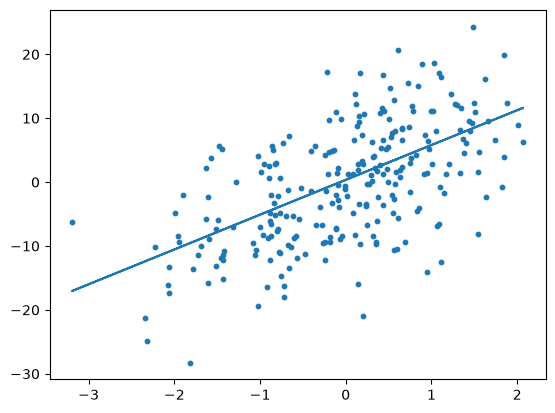

In [8]:
# 회귀 평가 지표
# 직선의 방정식 그려보자

x_axis = X_reg_test
y_axis = y_reg_test

# 1000개의 데이터는 산점도
plt.scatter(X_reg_test, y_reg_test, s=10)

plt.plot(X_reg_test, y_reg_pred)
plt.show()

In [9]:
# 분류 모델 AND GATE

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
print(knn.predict(np.array([[0, 0]])))
print(knn.predict(np.array([[0, 1]])))
print(knn.predict(np.array([[1, 0]])))
print(knn.predict(np.array([[1, 1]])))

[0]
[0]
[0]
[1]


In [10]:
# 분류 모델 OR GATE

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 1])
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
print(knn.predict(np.array([[0, 0]])))
print(knn.predict(np.array([[0, 1]])))
print(knn.predict(np.array([[1, 0]])))
print(knn.predict(np.array([[1, 1]])))

[0]
[1]
[1]
[1]


In [11]:
# 분류 모델 NAND GATE

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([1, 1, 1, 0])
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
print(knn.predict(np.array([[0, 0]])))
print(knn.predict(np.array([[0, 1]])))
print(knn.predict(np.array([[1, 0]])))
print(knn.predict(np.array([[1, 1]])))

[1]
[1]
[1]
[0]


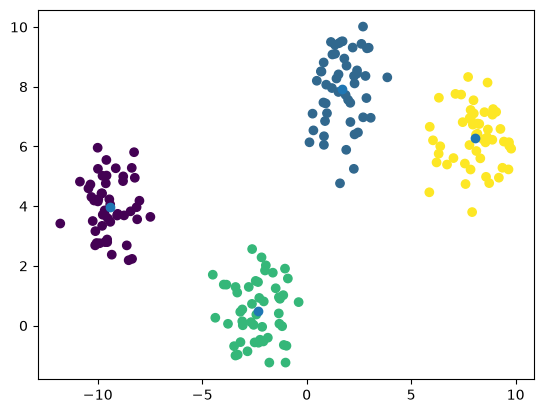

In [12]:
# 비지도 학습 (Unsupervised Learning) : 정답(Label) 이 없다
# 지도 학습 : 정답(Label)이 있다\
# 강화 학습 : 보상과 벌을 통해 학습

# Clustering (군집)
# K-Means Clustring
# K개의 중심점을 설정
# 모든 데이터를 설정한 K개 중 가장 가까운 중심점에 할당
# 각 중심점을 해당 군집으 ㅣ데이터 평균으로 이동

X_kmc, y_kmc = make_blobs(n_samples=200, n_features=2, centers=4, random_state=20, cluster_std=1.0)
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=20)
kmeans.fit(X_kmc)

# 시각화
# 중심점 좌표
centers = kmeans.cluster_centers_
labels = kmeans.labels_

plt.scatter(X_kmc[:, 0], X_kmc[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1])
plt.show()

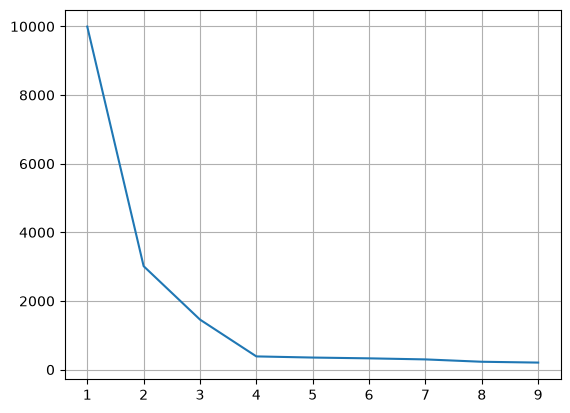

In [13]:
# elbow(엘보우) 기법 : n_cluster를 설정하기 위한 기법
k_list = range(1, 10)
inertia_list = []
for k in k_list:
    kmeans_elbow = KMeans(n_clusters=k, n_init="auto", random_state=20)
    kmeans_elbow.fit(X_kmc)

    inertia_list.append(kmeans_elbow.inertia_) # 군집 내 데이터들과 중심점 사이의 거리
plt.plot(k_list, inertia_list)
plt.grid(True)
plt.show()

# 팔꿈치의 검사가 완만해지는 구간의 k값이 4

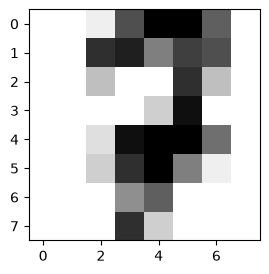

In [14]:
# 차원 축소
# 원본의 feature 가 많아 학습에 시간이 많이 소요될 때
# 원본의 정보를 최대한 담고 있는 새로운 데이터를 만들어 학습
digits = load_digits()
# 64개니까 8 X 8 로 그려보자
img = digits.images[300]

plt.figure(figsize=(3, 3))
# cmap="binary" : 흑백 , interpolation="nearest" : 선명하게
plt.imshow(img, cmap="binary", interpolation="nearest")
plt.show()

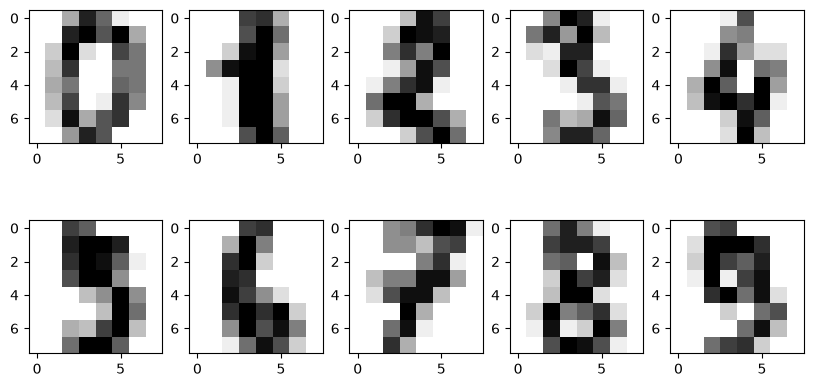

In [15]:
# 차원 축소
# 원본의 feature 가 많아 학습에 시간이 많이 소요될 때
# 원본의 정보를 최대한 담고 있는 새로운 데이터를 만들어 학습
digits = load_digits()
# 64개니까 8 X 8 로 그려보자

# canvas를 그리자
fig, axis = plt.subplots(2, 5, figsize=(10, 5))
for i in range(2):
    for j in range(5):
        axis[i, j].imshow(digits.images[i*5 + j], cmap="binary", interpolation="nearest")
        # [1, 0] => 5 이므로
plt.show()


원본 데이터의 차원 :(1797, 64)
축소된 데이터의 차원: (1797, 2)
0.29


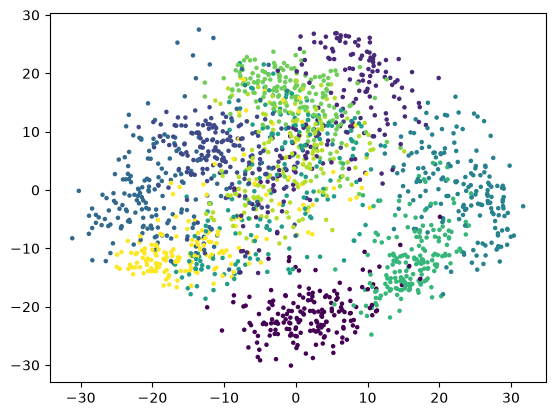

In [16]:
# 차원 축소
X = digits.data
y = digits.target
print(f"원본 데이터의 차원 :{X.shape}")

# 주성분 PCA(Principal Component Analysis)
# 원리 : 데이터의 분산(Variance)이 가장 큰 방향으로 축소

pca = PCA(n_components=2) # 64 -> 2
X_pca = pca.fit_transform(X)
print(f"축소된 데이터의 차원: {X_pca.shape}")

# print(pca.explained_variance_ratio_)      # [0.14890594 0.13618771]
# 축소된 데이터가 원본을 얼마나 잘 설명하고 있는지
print(round(sum(pca.explained_variance_ratio_), 2)) # 0.29

# 시각화
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=5)
plt.show()

In [17]:
# 원-핫 인코딩 (One-Hot Encoding)
df_titanic = pd.read_csv("titanic.csv")
df_titanic["Sex"]
# 성별이 문자열이므로 머신 러닝을 위해 수치로 변환을 원한다
# 어제 female -> 1 , male -> 0 으로 바꿈 -> 학습 : Sex의 1이 좀 더 중요하고 0은 안 중요하구나
# 단순히 학습 위해 수치로 바꾸었는데 의미를 가져 버림
# male 이라는 column을 만들어 male 이면 1, 아니면 0
# female 이라는 column을 만들어 female이면 1, 아니면 0
df_tt = df_titanic.copy()
df_tt["female"] = df_tt["Sex"].apply(lambda x : 1 if x == "female" else 0)
df_tt["male"] = df_tt["Sex"].apply(lambda x : 1 if x == "male" else 0)



# pandas 내의 원-핫 인코딩 (One-Hot Encoding) 
df_tt["Embarked"].unique() # S column 만들어서 S 면 1, C column 만들어서 C면 1
df_tt = pd.get_dummies(df_tt, columns=["Embarked"], dtype=int)
df_tt = df_tt[["Pclass","female", "male", "Age", "Embarked_C", "Embarked_Q", "Embarked_S", "Survived"]]
df_tt = df_tt.dropna()
X =df_tt.iloc[:,:-1]
y =df_tt.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)
# 1) 모델 설정 (KNN, 결정트리, SVM)

In [18]:
# KNN
knn = KNeighborsClassifier(n_neighbors=3)

knn = knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.7877


In [19]:
# Decision tree
d_tree = DecisionTreeClassifier(max_depth=3)

d_tree = d_tree.fit(X_train, y_train)
y_pred = d_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.7430


In [20]:
# SVM
svc = SVC(kernel="rbf", C=1.0, random_state=100)
scaler_tt = StandardScaler()

X_train_scaled = scaler_tt.fit_transform(X_train)
X_test_scaled = scaler_tt.transform(X_test)

svc.fit(X_train_scaled ,y_train)
y_pred = svc.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.8436


In [21]:
df_titanic = pd.read_csv("titanic.csv")
df_tt = df_titanic.copy()
df_tt["female"] = df_tt["Sex"].apply(lambda x : 1 if x == "female" else 0)
df_tt["male"] = df_tt["Sex"].apply(lambda x : 1 if x == "male" else 0)
df_tt = pd.get_dummies(df_tt, columns=["Embarked"], dtype=int)
df_tt = df_tt[["Pclass", "female", "male", "Age", "Embarked_C", "Embarked_Q", "Embarked_S", "Survived"]]
df_tt = df_tt.dropna()
X = df_tt.iloc[:, :-1]
y = df_tt.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)


In [22]:
# Logistic Regression
# sigmoid function
# 사실 분류임 데이터 특성을 잘 표현할 수 있는 직선을 그리고 해당 직선을 sigmoid function을 활용해 0과 1 사이로 표현
# 0.5 이상이면 True, 0.5 미만이면 False 

lr_tt = LogisticRegression(solver="lbfgs", C=1.0, max_iter=100)

lr_tt.fit(X_train, y_train)
y_pred = lr_tt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.7877


In [34]:
# Confusion Matrix(혼돈 행렬, 오차행렬) : 좋은 모델을 만들었는가에 대한 평가지표

# 암환자를 판단하는 모델!!
# testcase : 100
# 실제 암환자 : 5명, 정상 : 95명
# 모델 만들기 귀찮으니까 다 정상이라고 하자 => 95% 의 정확도
# 정확도 만으로 모든 성능을 나타낼 수 없다@@


# 예측 : 암환자 : positive , 정상 : nagative
# 정확도 : 맞춤 : True       틀림 : False
# 그럼 네가지 경우의 수 True positive, True nagative , Flase positivem,  Flase negative
# TP : 암환자고 맞춤
# TN : 정상이고 맞춤
# FP : 정상인데 틀림
# FN : 암환자데 틀림

# 모든 대상을 암이 아니다!! 라고 예측할시
# 1) 정확도 (accuracy)
#            정답 ( TP(0) + TN(95) )
# ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
#  모든 경우의 수 ( TP(0) + TN(95) + FP(0) + FN(5) )
# 이 모델 의 정확도 : 0.95

# 2) 재현율 (Recall)
# 실제 정답 중 정확히 맞춘 비율
#       암 환자를 맞춤 (TP(0))
# ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
#      실제 암환자(TP(0) + FN(5))

# 3) 정밀도 (Precision)
# True 인 것 중 Positive 인 비율
#       TP(0)
# ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
#   TP(0) + TN(95)



# 만약 TP : 3 , FN : 5, FP : 2, TN : 90 일떄,
# 1) accuracy : 0.93
# 2) Recall : 0.375
# 3) precision : 0.032
# 4) f1-score(rp조화평균)
# 2/((1/r)+(1/p))  = (2*rp)/r+p  = f1-score      r = 0.375, p = 0.032
# r = 0.375
# p = 0.032
# print(f"{2/((1/r)+(1/p)):.4f}")
# 조화평균 = 0.0590


cm = confusion_matrix(y_test, y_pred, labels=[1, 0]) # TP, FN, FP, TN
# 타이타닉 데이터 분석
# Positive -> 생존 예측
# Nagative -> 생존이 아님
# True -> 정답
# False -> 오답
# TP -> 생존 예측 -> 실제 생존
# FN -> 생존이 아님 예측 -> 실제 생존
# FP -> 생존 예측 -> 실제 생존이 아님
# TN -> 생존이 아님 예측 -> 실제 생존이 아님
# TP = cm[0, 0]
# FN = cm[0, 1]
# FP = cm[1, 0]
# TN = cm[1, 1]
[[TP, FN],
 [FP, TN]] = cm
# 1) 정확도(Accuracy)
a = (TP + TN) / (TP + FN + FP + TN)
# 2) 재현율(Recall)
r = (TP) / (TP + FN)
# 3) 정밀도(Precision)
p = (TP) / (TP + FP)
# 4) f1-score(rp조화평균) = (2 * r * p) / (r + p)
f1 = (2 * r * p) / (r + p)
print(accuracy_score(y_test, y_pred), a)
print(recall_score(y_test, y_pred), r)
print(precision_score(y_test, y_pred), p)
print(f1_score(y_test, y_pred), f1)

print(classification_report(y_test, y_pred))

0.7877094972067039 0.7877094972067039
0.6623376623376623 0.6623376623376623
0.8095238095238095 0.8095238095238095
0.7285714285714285 0.7285714285714286
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       102
           1       0.81      0.66      0.73        77

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.78       179



In [24]:
# deep running basic
# 관련 라이브러리 설치
# !pip install --upgrade pip
# GPU 환경에서 딥러닝 하려면
# 해당 GPU 버전에 맞는 tensorflow를 설치해야함
# 지금 CPU에서 돌려보고 힘들면 GPU
# !pip install tensorflow        #2.21 설치됨, keras 3.15 설치됨 GPU RTX 4060 8GB gen intel core i7 13700




2.3
79.0


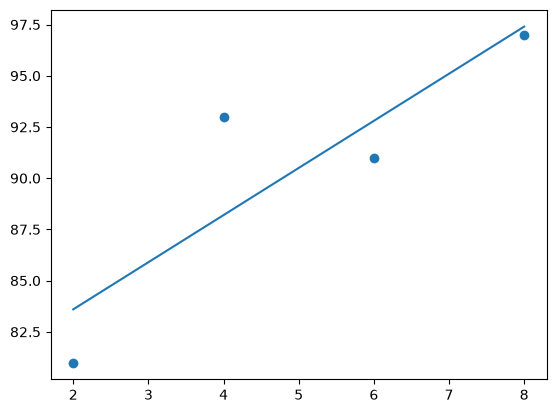

In [25]:
# 단순 선형 회귀 

X = np.array([2, 4, 6, 8])
Y = np.array([81, 93, 91,97])

# y = a*x_b    a 는 기울기 b는 y절편
def custom_model(x):
    return a * x + b

X_mean = np.mean(X)
Y_mean = np.mean(Y)
# a = (x-x평균)(y-y평균)의 합/(x-x평균)^2의 합
a = np.sum((X-X_mean)*(Y-Y_mean)) / np.sum((X-X_mean)**2)
print(a)
b = Y_mean - (X_mean*a)
print(b)
plt.scatter(X, Y)
X_range = range(2, 9)
plt.plot(X_range, a*X_range+b)
plt.show()

# simple linear regression (단순선형회귀) :  input 1차원(feature 가 1개)일 떄, 선형회귀로 직선의 방정식


In [26]:
# 머신러닝 -> 딥러닝
# machine running :  y = a * x +b

# Hypothesis (가설 함수)
# 가중치 w (weight)
# 편향 b(bias)
# MAE, MSE, RMSE
# deep running 에서 손실함수 (lossfunction)
# 머신러닝 경사하강법 = 딥러닝 optimizer
# 순전파와 역전파 
# H = w * x + b

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

import pandas as pd

In [ ]:
# 나만의 모델
model = Sequential()
model.add(Dense(12,input_dim=7, activation="relu")) # relu : 양수 y = x , 음수 = 0
model.add(Dense(8,input_dim=12, activation="relu")) # 윗 층에서 노드가 12이니 이곳 input_dim은 12 (but 생략가능)
model.add(Dense(1,input_dim=8, activation="sigmoid"))
# sigmoid function
# 사실 분류임 데이터 특성을 잘 표현할 수 있는 직선을 그리고 해당 직선을 sigmoid function을 활용해 0과 1 사이로 표현
# 0.5 이상이면 True, 0.5 미만이면 False

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

X = df_tt.iloc[:, :-1]
y = df_tt.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)
model.fit(X_train,y_train, epochs=200, batch_size=64)
# Epoch : 학습 횟수
# batch_size : 한 번 학습 시 해당 개수만큼 보아라



Epoch 1/200


C:\Users\kccistc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6019 - loss: 1.4848  
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6019 - loss: 1.1880 
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6056 - loss: 0.9442 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6075 - loss: 0.7629 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6112 - loss: 0.6700 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6150 - loss: 0.6530 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6093 - loss: 0.6525 
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6477 
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6431 
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6408 
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6390 
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6365 


In [ ]:
# test데이터를 통해 얼마나 모델의 성능이 높은지
print(model.evaluate(X_test, y_test)[0])
print(model.evaluate(X_test, y_test)[1]) # (loss, accuracy)

# softmax function : 3개 이상의 클래스를 판별하는 로직
# 각 class 의 확률을 계산하여 가장 높은 확률을 가진 클래스로 분류

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8045 - loss: 0.4234 
0.4234206974506378
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8045 - loss: 0.4234 
0.8044692873954773


In [1]:
# deep running 활용 iris data 예측

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [12]:
iris_dataset = load_iris()
X = iris_dataset.data
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 20)

model = Sequential()
model.add(Dense(12, input_dim=4, activation="relu"))
model.add(Dense(8, input_dim=12, activation="relu"))
 # class 3개 이상 마지막 층 노드 개수 -> class 개수
 
model.add(Dense(3, input_dim=8, activation="softmax"))

# 컴파일
# 오차 함수
# 이진 분류 -> binary_crossentropy
# 3개 이상 분류 -> softmax
# 오차 줄이는 방식 -> adam
# 평가방식 -> accuracy
model.compile(loss = "sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()
model.fit(X_train, y_train, epochs=200, batch_size=16)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.8860  
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.7161 
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3393 - loss: 1.5759 
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.4529 
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.3505 
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.2601 
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - loss: 1.1857 
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3393 - loss: 1.1243 
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3393 - loss: 1.0783 
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3393 - loss: 1.0437 
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3393 - loss: 1.0134 
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3393 - lo

In [13]:
print(model.evaluate(X_test, y_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9474 - loss: 0.2129
[0.2128533273935318, 0.9473684430122375]


In [ ]:
# 학습 회수(epochs)걀장
# 배치 사이즈 (batch_size) 결정
# 층을 몇 개 만들 것인가?
# 각 층의 노드는 몇 개 할 것인가
# 각 층의 활성화 함수는 어떤 걸 쓸 것인가? relu
# 오차 함수 어떤 걸 쓸 것인가
# optimizer 어떤 걸 쓸 것인가


# AI 모델링 X
# AI 엔지니어링

# AI 모델링 -> binary_crossentropy 대신에 내가 만든 오차 함수
# 내가 만든 활성화 함수쓴다.
# 해당 활성화 함수 뜯어서 내 생각을 5% 반영해서 새로운 활성화 함수

# AI모델링 -> 대학원 석사 -> 취업할 수 있나요? -> 안됨
# 랩에 90% 이상이 공기업 취업, 박사
# 시장 aI 석사 -> 관련 경력 3년 있으세요?
# AI 석사 -> 연봉 4천 ->

In [22]:
iris_dataset = load_iris()
X = iris_dataset.data
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 20)

model = Sequential()
model.add(Dense(12, input_dim=4, activation="relu"))
model.add(Dense(8, input_dim=12, activation="relu"))
 # class 3개 이상 마지막 층 노드 개수 -> class 개수
 
model.add(Dense(1, input_dim=8, activation="softmax"))

# 컴파일
# 오차 함수
# 이진 분류 -> binary_crossentropy
# 3개 이상 분류 -> softmax
# 오차 줄이는 방식 -> adam
# 평가방식 -> accuracy
model.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()
model.fit(X_train, y_train, epochs=200, batch_size=16)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173 (692.00 B)

 Trainable params: 173 (692.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00  
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 0.0000e+00 
Epoch 12/200
7/7 ━━━━━━━━━━━━

In [23]:
print(model.evaluate(X_test, y_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3684 - loss: 0.0000e+00
[0.0, 0.3684210479259491]


C:\Users\kccistc\AppData\Roaming\Python\Python313\site-packages\keras\src\ops\nn.py:959: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\kccistc\AppData\Roaming\Python\Python313\site-packages\keras\src\losses\losses.py:34: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


In [20]:
df_ir = load_iris()
X = df_ir.data
y = df_ir.target
y = to_categorical(y) #y값을 ONE-HOT ENCODING

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.75,test_size=0.25)

model= Sequential()
model.add(Dense(12,input_dim=4,activation="relu"))
model.add(Dense(8,input_dim=12,activation="relu"))
model.add(Dense(8,input_dim=8,activation="relu"))
model.add(Dense(3,input_dim=8,activation="softmax"))

model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model.fit(X_train,y_train,epochs=300,batch_size=16)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3482 - loss: 1.9883  
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.7719 
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.6168 
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.5045 
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.3962 
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.3245 
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.2752 
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.2336 
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.1979 
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.1742 
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - loss: 1.1574 
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3482 - lo

In [21]:
print(model.evaluate(X_test, y_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0204
[0.020384663715958595, 1.0]
